In [1]:
%pip install pandas numpy

Note: you may need to restart the kernel to use updated packages.


In [2]:
##IMPORTING THE CLEANED DATA
import pandas as pd
import numpy as np

data = pd.read_csv("LA_Assault_Data_2020_Present.csv")

In [3]:
##CONVERTING TO DATETIME
data["DATE OCC"] = pd.to_datetime(data["DATE OCC"])

In [4]:
##CREATING TIME VARIABLES
data["year"] = data["DATE OCC"].dt.year
data["month"] = data["DATE OCC"].dt.month
data["day_of_week"] = data["DATE OCC"].dt.dayofweek

In [5]:
##ESTABLISHING SPATIAL GRID CELLS

##0.01 degrees ≈ ~1km
grid_size = 0.01

data["lat_grid"] = (data["LAT"] // grid_size) * grid_size
data["lon_grid"] = (data["LON"] // grid_size) * grid_size

In [6]:
##CREATING A SPATIOTEMPORAL DATASET

crime_grid = (
    data.groupby(["lat_grid","lon_grid","year","month"])
    .size()
    .reset_index(name="crime_count")
)
##each row should represent a grid-cell and a time period

In [7]:
# Create full monthly time index
all_months = pd.date_range(
    start=data["DATE OCC"].min(),
    end=data["DATE OCC"].max(),
    freq="MS"
)

# Create full grid-time combinations
grid_index = pd.MultiIndex.from_product(
    [crime_grid["lat_grid"].unique(),
     crime_grid["lon_grid"].unique(),
     all_months],
    names=["lat_grid","lon_grid","date"]
)

full_grid = pd.DataFrame(index=grid_index).reset_index()

# Extract year/month
full_grid["year"] = full_grid["date"].dt.year
full_grid["month"] = full_grid["date"].dt.month

# Merge with crime counts
crime_grid = full_grid.merge(
    crime_grid,
    on=["lat_grid","lon_grid","year","month"],
    how="left"
)

# Fill missing crime counts
crime_grid["crime_count"] = crime_grid["crime_count"].fillna(0)

In [8]:
##ADDING LAG FEATURES
crime_grid = crime_grid.sort_values(["lat_grid", "lon_grid", "date"])

crime_grid["lag_1"] = crime_grid.groupby(["lat_grid", "lon_grid"])["crime_count"].shift(1)
crime_grid["lag_3"] = crime_grid.groupby(["lat_grid", "lon_grid"])["crime_count"].shift(3)
crime_grid["lag_6"] = crime_grid.groupby(["lat_grid", "lon_grid"])["crime_count"].shift(6)

In [9]:
crime_grid = crime_grid.groupby(["lat_grid","lon_grid"]).filter(
    lambda x: x["crime_count"].sum() > 0
)

In [10]:
crime_grid = crime_grid.dropna(subset=["lag_1","lag_3","lag_6"])

<h2>Random Forest Model</h2>
<p>One of the first models</p>

In [11]:
train = crime_grid[crime_grid["year"] < 2022]
test = crime_grid[crime_grid["year"] >= 2022]

print(train.shape)
print(test.shape)

(21168, 9)
(14112, 9)


In [12]:
features = ["lat_grid", "lon_grid", "month", "lag_1", "lag_3", "lag_6"]

X_train = train[features]
y_train = train["crime_count"]

X_test = test[features]
y_test = test["crime_count"]

In [15]:
##Fitting Random Forest
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [16]:
##Prediciting
pred_rf = rf_model.predict(X_test)

In [18]:
##Evaluating

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))

print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)


Random Forest MAE: 1.1484170603776622
Random Forest RMSE: 2.1678931444979774


In [20]:
##Comparing To Baseline
mae = 1.0908197343812427
rmse = 2.3333593436303555

print("Baseline Regression MAE:", mae)
print("Baseline Regression RMSE:", rmse)

print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)

Baseline Regression MAE: 1.0908197343812427
Baseline Regression RMSE: 2.3333593436303555
Random Forest MAE: 1.1484170603776622
Random Forest RMSE: 2.1678931444979774


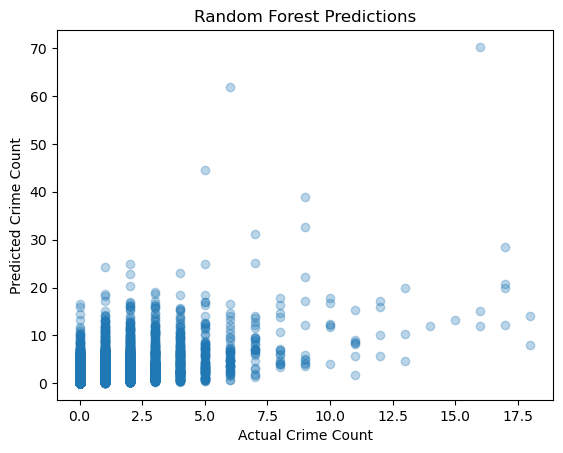

In [22]:
##Plotting Predicted vs Actual
import matplotlib.pyplot as plt

plt.scatter(y_test, pred_rf, alpha=0.3)
plt.xlabel("Actual Crime Count")
plt.ylabel("Predicted Crime Count")
plt.title("Random Forest Predictions")
plt.show()

In [23]:
##Feature Importance
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

importance_df

,Feature,Importance
3,lag_1,0.658187
4,lag_3,0.162411
5,lag_6,0.096051
1,lon_grid,0.035039
0,lat_grid,0.025183
2,month,0.023129
